In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import os
os.chdir('..')

df = pd.read_csv("data/processed/01_initial_cleaned.csv")


1. DETECT

In [2]:
# tổng quan missing
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_pct = total_missing / total_cells * 100

print(f"Tổng số ô dữ liệu     : {total_cells:,}")
print(f"Tổng số ô missing     : {total_missing:,} ({missing_pct:.2f}%)")
print(f"Tỷ lệ dữ liệu sạch    : {100 - missing_pct:.2f}%\n")

Tổng số ô dữ liệu     : 531,011
Tổng số ô missing     : 84,501 (15.91%)
Tỷ lệ dữ liệu sạch    : 84.09%



Nhận xét:
- Sau khi lọc dữ liệu theo phạm vi nghiên cứu, tổng tỷ lệ missing giảm còn 15.91%, thấp hơn đáng kể so với dataset gốc (19.48%), cho thấy chất lượng dữ liệu đã được cải thiện.
- Tỷ lệ dữ liệu sạch đạt 84.09%, phản ánh phần lớn dữ liệu trong giai đoạn nghiên cứu đã tương đối đầy đủ và phù hợp cho phân tích.
- Việc loại bỏ các giai đoạn lịch sử có quá nhiều giá trị thiếu giúp giảm nhiễu và tăng độ tin cậy cho các bước tiền xử lý, phân tích và xây dựng mô hình sau này.

In [3]:
# Chi tiết missing theo cột (chỉ hiển thị cột có missing)
missing_detail = pd.DataFrame({
    'Số missing': df.isnull().sum(),
    'Tỷ lệ (%)': (df.isnull().mean() * 100).round(2)
}).sort_values('Tỷ lệ (%)', ascending=False)

print("=== CHI TIẾT MISSING THEO TỪNG CỘT ===")
print(missing_detail[missing_detail['Số missing'] > 0])

=== CHI TIẾT MISSING THEO TỪNG CỘT ===
          Số missing  Tỷ lệ (%)
SUBBASIN       34715      84.99
WMO_WIND       27196      66.58
WMO_PRES       21677      53.07
NATURE           913       2.24


Nhận xét:
- Sau khi lọc dữ liệu, biến NATURE chỉ còn thiếu 2.24%, cho thấy thuộc tính này tương đối đầy đủ và có thể sử dụng ổn định trong phân tích.
- Hai biến khí tượng chính WMO_WIND và WMO_PRES vẫn còn tỷ lệ missing khá cao (66.58% và 53.07%), phản ánh dữ liệu cường độ bão chưa được ghi nhận đầy đủ trong nhiều trường hợp.
- Biến SUBBASIN tiếp tục có tỷ lệ thiếu rất lớn (84.99%), cho thấy thuộc tính này không phù hợp để khai thác trong phạm vi nghiên cứu hiện tại.
- So với dataset gốc, mức độ missing của các biến đã giảm, đặc biệt ở WMO_PRES và NATURE, giúp cải thiện chất lượng dữ liệu sau bước lọc.

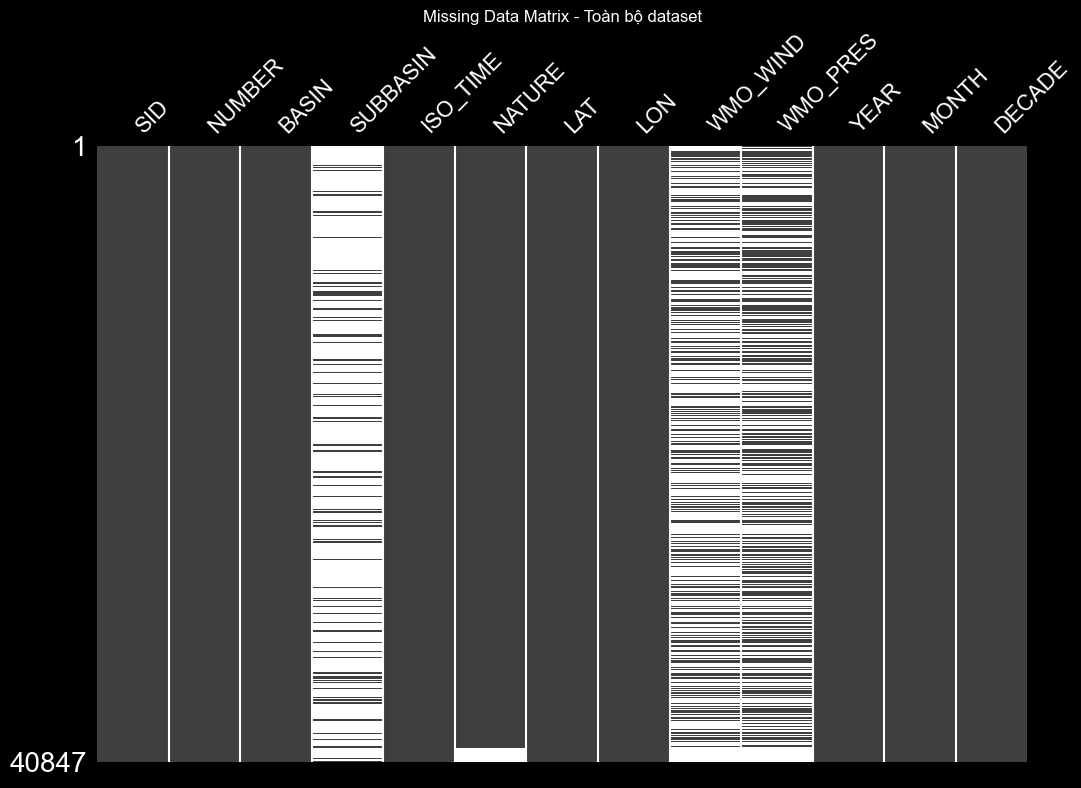

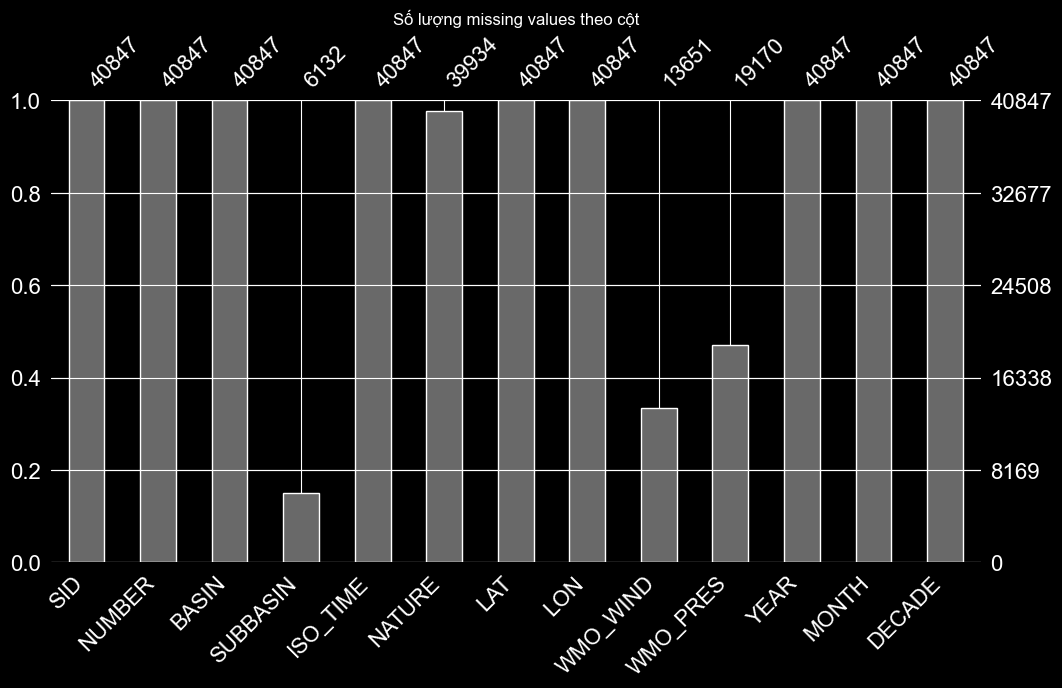

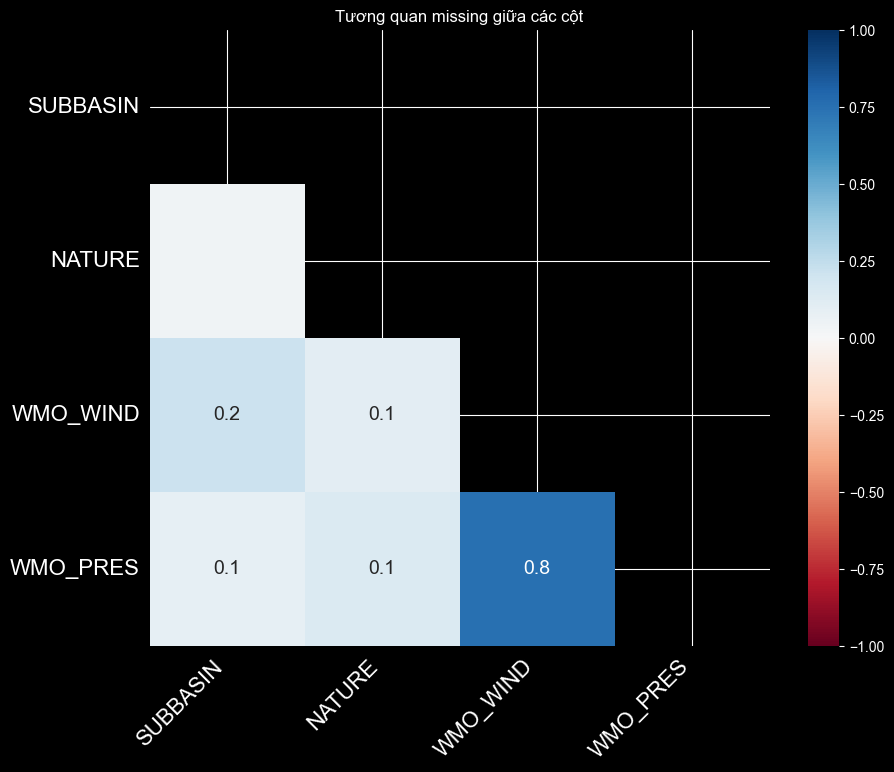

In [4]:
# Visualization Missing Pattern

# Matrix
msno.matrix(df, figsize=(12, 8), sparkline=False)
plt.title('Missing Data Matrix - Toàn bộ dataset')
plt.show()

# Bar chart
msno.bar(df, figsize=(12, 6))
plt.title('Số lượng missing values theo cột')
plt.show()

# Heatmap tương quan
msno.heatmap(df, figsize=(10, 8))
plt.title('Tương quan missing giữa các cột')
plt.show()


Nhận xét:
- Phân bố missing theo thời gian (Matrix):

 Sau khi sort theo SID, ISO_TIME, WMO_WIND và WMO_PRES hiện các vạch trắng tập trung dày ở phần đầu dataset rồi thưa dần - cho thấy một nhóm cơn bão thiếu hoàn toàn WMO data (tạo khối trắng liền), trong khi các storm còn lại chỉ thiếu một phần track. SUBBASIN trắng theo khối lớn liên tục do toàn bộ track của một số basin không có thông tin này - mang tính cấu trúc của IBTrACS, không phải lỗi dữ liệu. Các biến định danh và tọa độ hoàn toàn đầy đủ xuyên suốt.
- Tỷ lệ missing (Bar chart):

WMO_WIND (\~33%) và WMO_PRES (\~47%) có tỷ lệ missing cao nhất trong các biến cần phân tích. NATURE chỉ thiếu \~2.2%, không đáng kể. Các biến định danh/địa lý đạt 100% completeness.
- Tương quan missing (Heatmap):

WMO_WIND và WMO_PRES có tương quan missing r = 0.8 - hai biến gần như luôn thiếu đồng thời trên cùng một quan sát. Điều này cho thấy missing của hai biến có chung nguồn gốc, không độc lập với nhau - là bằng chứng cho thấy missing không phải ngẫu nhiên (MCAR). Các cặp biến còn lại có tương quan ≤ 0.2, gần như độc lập.

=> Missing data trong dataset có cấu trúc rõ ràng và mang tính hệ thống theo thời gian cũng như phương pháp quan trắc, thay vì phân bố ngẫu nhiên. Tương quan missing cao giữa WMO_WIND và WMO_PRES cho thấy hai biến thường thiếu đồng thời và nhiều khả năng chịu ảnh hưởng từ cùng một cơ chế phát sinh missing. Những dấu hiệu này cho thấy giả thuyết MCAR có thể không phù hợp với dữ liệu. Do đó, nghiên cứu tiếp tục phân tích missing theo BASIN và DECADE nhằm thu thập thêm bằng chứng và xác định cơ chế missing phù hợp nhất trước khi thực hiện imputation.

2. INVESTIGATE

In [5]:
# Phân tích pattern missing để xác nhận MAR
# WMO_WIND
print("--- Tỷ lệ missing WMO_WIND theo DECADE (%) ---")
print(df.groupby('DECADE')['WMO_WIND'].apply(lambda x: x.isnull().mean()*100).round(2))

print("\n--- Tỷ lệ missing WMO_WIND theo BASIN (%) ---")
print(df.groupby('BASIN')['WMO_WIND'].apply(lambda x: x.isnull().mean()*100).round(2))

print("\n--- So sánh LAT khi WMO_WIND missing vs không missing ---")
print(df.groupby(df['WMO_WIND'].isnull())['LAT'].describe().round(2))

# WMO_PRES
print("\n--- Tỷ lệ missing WMO_PRES theo DECADE (%) ---")
print(df.groupby('DECADE')['WMO_PRES'].apply(lambda x: x.isnull().mean()*100).round(2))

print("\n--- Tỷ lệ missing WMO_PRES theo BASIN (%) ---")
print(df.groupby('BASIN')['WMO_PRES'].apply(lambda x: x.isnull().mean()*100).round(2))

print("\n--- So sánh LAT khi WMO_PRES missing vs không missing ---")
print(df.groupby(df['WMO_PRES'].isnull())['LAT'].describe().round(2))

--- Tỷ lệ missing WMO_WIND theo DECADE (%) ---
DECADE
2000    66.54
2010    65.04
2020    69.51
Name: WMO_WIND, dtype: float64

--- Tỷ lệ missing WMO_WIND theo BASIN (%) ---
BASIN
Eastern North Pacific    80.92
North India              40.51
South Indian             56.63
Western North Pacific    70.96
Name: WMO_WIND, dtype: float64

--- So sánh LAT khi WMO_WIND missing vs không missing ---
            count   mean    std   min   25%   50%   75%   max
WMO_WIND                                                     
False     13651.0  19.07   8.37 -27.4  14.3  19.2  24.0  46.9
True      27196.0  19.07  11.17 -28.5  12.1  17.2  22.6  61.7

--- Tỷ lệ missing WMO_PRES theo DECADE (%) ---
DECADE
2000    53.08
2010    50.67
2020    57.49
Name: WMO_PRES, dtype: float64

--- Tỷ lệ missing WMO_PRES theo BASIN (%) ---
BASIN
Eastern North Pacific    78.63
North India              40.63
South Indian             54.35
Western North Pacific    54.95
Name: WMO_PRES, dtype: float64

--- So sánh LAT khi W

Nhận xét:
- WMO_WIND

Tỷ lệ missing ổn định qua các thập kỷ (~65–70%), không có xu hướng cải thiện rõ trong 2000–2025, cho thấy đây là đặc điểm cố định của dataset, không phải vấn đề thời gian. Theo BASIN, Eastern North Pacific cao nhất (80.92%), North India thấp nhất (40.51%). So sánh LAT: mean hoàn toàn bằng nhau (19.07 vs 19.07) => vị trí địa lý không phải yếu tố quyết định missing.

- WMO_PRES

Missing ổn định theo thập kỷ (~51–57%), không cải thiện trong 2000–2025. Theo BASIN, Eastern North Pacific cao nhất (78.63%), North India thấp nhất (40.63%). So sánh LAT: nhóm missing có mean thấp hơn (17.89 vs 20.40) - có tương quan nhất định với vị trí địa lý, nhưng BASIN vẫn là yếu tố chủ đạo.

**Tại sao missing phụ thuộc vào BASIN - cơ chế IBTrACS:**

WMO_WIND/PRES chỉ được gán từ WMO agency chính thức của từng basin (WNP=JMA, ENP=NHC, NI=IMD...) → khi agency không báo cáo tại một timestep, cả hai NaN dù JTWC/CMA có dữ liệu. Vì mỗi basin có agency khác nhau nên tỷ lệ missing chênh theo BASIN (40%→80%), thiếu đồng thời (r=0.8), và ổn định qua thập kỷ - đều là đặc điểm cấu trúc, không phải lỗi ngẫu nhiên.

=> Missing của WMO_WIND và WMO_PRES có liên hệ với BASIN (và LAT đối với WMO_PRES) – đều là các biến quan sát được. Điều này ủng hộ cơ chế MAR và là cơ sở để loại bỏ giả thuyết MCAR.

In [6]:
# Phân tích pattern missing để xác nhận MAR
# Kiểm tra SUBBASIN missing theo BASIN
print("--- SUBBASIN missing theo BASIN (%) ---")
print(df.groupby('BASIN')['SUBBASIN'].apply(
    lambda x: x.isnull().mean()*100).round(2))

# Kiểm tra SUBBASIN missing theo DECADE
print("--- SUBBASIN missing theo DECADE (%) ---")
print(df.groupby('DECADE')['SUBBASIN'].apply(lambda x: x.isnull().mean()*100).round(2))

# Kiểm tra NATURE missing theo BASIN
print("\n--- NATURE missing theo BASIN (%) ---")
print(df.groupby('BASIN')['NATURE'].apply(
    lambda x: x.isnull().mean()*100).round(2))

# Kiểm tra NATURE missing theo DECADE
print("\n--- NATURE missing theo DECADE (%) ---")
print(df.groupby('DECADE')['NATURE'].apply(
    lambda x: x.isnull().mean()*100).round(2))

--- SUBBASIN missing theo BASIN (%) ---
BASIN
Eastern North Pacific      0.00
North India                0.00
South Indian              41.23
Western North Pacific    100.00
Name: SUBBASIN, dtype: float64
--- SUBBASIN missing theo DECADE (%) ---
DECADE
2000    85.63
2010    85.80
2020    82.32
Name: SUBBASIN, dtype: float64

--- NATURE missing theo BASIN (%) ---
BASIN
Eastern North Pacific    0.00
North India              0.85
South Indian             0.00
Western North Pacific    2.52
Name: NATURE, dtype: float64

--- NATURE missing theo DECADE (%) ---
DECADE
2000     0.01
2010     0.01
2020    10.33
Name: NATURE, dtype: float64


Nhận xét:
- SUBBASIN

Missing phụ thuộc hoàn toàn vào BASIN: Western North Pacific 100% missing, South Indian 41.23%, trong khi Eastern North Pacific và North India hoàn toàn đầy đủ. Tỷ lệ ổn định theo thập kỷ (~82–86%) - đây là đặc điểm cấu trúc của IBTrACS, không phải lỗi dữ liệu. → MAR.

- NATURE

Missing rất thấp theo BASIN (0–2.52%) và ổn định ở 2000–2010 (~0.01%), nhưng tăng đột biến lên 10.33% ở thập kỷ 2020 - có thể do thay đổi cách ghi nhận trong phiên bản IBTrACS gần đây. Missing phụ thuộc vào thập kỷ - biến quan sát được → MAR.

3. IMPUTE

=== PHÂN TÍCH ĐỘ DÀI GAP MISSING THEO STORM ===

--- WMO_WIND ---
  Số storm có gap > 0      : 582
  Gap lớn nhất             : 120 điểm (360h)
  Gap trung bình (có gap)  : 18.1 điểm
  Gap median (có gap)      : 16 điểm
  Storms NaN toàn track    : 128
  Phân bố gap (partial-data storms):
    0 điểm  (no gap)            :     9 storms (1.5%)
    1-7 điểm  (≤21h)            :   119 storms (20.1%)
    8-15 điểm (24-45h)          :   169 storms (28.6%)
    >15 điểm  (>45h)            :   294 storms (49.7%)

--- WMO_PRES ---
  Số storm có gap > 0      : 582
  Gap lớn nhất             : 94 điểm (282h)
  Gap trung bình (có gap)  : 6.1 điểm
  Gap median (có gap)      : 3 điểm
  Storms NaN toàn track    : 128
  Phân bố gap (partial-data storms):
    0 điểm  (no gap)            :     9 storms (1.5%)
    1-7 điểm  (≤21h)            :   434 storms (73.4%)
    8-15 điểm (24-45h)          :    99 storms (16.8%)
    >15 điểm  (>45h)            :    49 storms (8.3%)



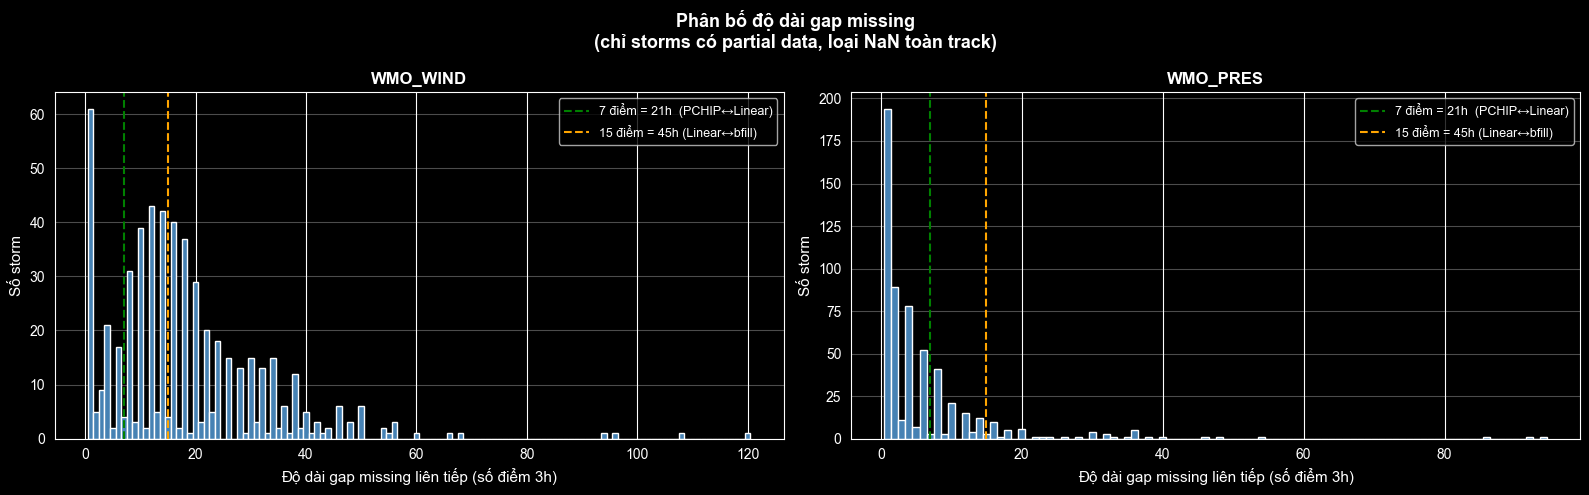

In [7]:
def max_consecutive_nan(series):
    """Trả về độ dài gap missing dài nhất trong 1 series."""
    max_gap = cur_gap = 0
    for v in series:
        if pd.isna(v):
            cur_gap += 1
            max_gap = max(max_gap, cur_gap)
        else:
            cur_gap = 0
    return max_gap

print("=== PHÂN TÍCH ĐỘ DÀI GAP MISSING THEO STORM ===\n")

gap_data = {}  # lưu lại để vẽ histogram

for col in ['WMO_WIND', 'WMO_PRES']:
    gap_per_storm = df.groupby('SID')[col].apply(max_consecutive_nan)
    storm_len     = df.groupby('SID')[col].apply(len)
    # Chỉ giữ storms có partial data (loại NaN toàn track)
    gap_filtered  = gap_per_storm[gap_per_storm < storm_len]
    gap_data[col] = gap_filtered   # lưu để vẽ

    n_nan_all = (gap_per_storm == storm_len).sum()

    print(f"--- {col} ---")
    print(f"  Số storm có gap > 0      : {(gap_filtered > 0).sum()}")
    print(f"  Gap lớn nhất             : {gap_filtered.max()} điểm ({gap_filtered.max()*3}h)")
    print(f"  Gap trung bình (có gap)  : {gap_filtered[gap_filtered>0].mean():.1f} điểm")
    print(f"  Gap median (có gap)      : {gap_filtered[gap_filtered>0].median():.0f} điểm")
    print(f"  Storms NaN toàn track    : {n_nan_all}")

    groups = [
        ('0 điểm  (no gap)',    lambda x: x == 0),
        ('1-7 điểm  (≤21h)',   lambda x: (x >= 1) & (x <= 7)),
        ('8-15 điểm (24-45h)', lambda x: (x >= 8) & (x <= 15)),
        ('>15 điểm  (>45h)',   lambda x: x > 15),
    ]
    print(f"  Phân bố gap (partial-data storms):")
    for lbl, cond in groups:
        cnt = cond(gap_filtered).sum()
        pct = cnt / len(gap_filtered) * 100
        print(f"    {lbl:28s}: {cnt:5,} storms ({pct:.1f}%)")
    print()

# Histogram song song cho cả hai biến
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phân bố độ dài gap missing\n(chỉ storms có partial data, loại NaN toàn track)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['WMO_WIND', 'WMO_PRES']):
    gf = gap_data[col]
    gf_pos = gf[gf > 0]
    ax.hist(gf_pos, bins=range(1, int(gf_pos.max())+2),
            color='steelblue', edgecolor='white', align='left')
    ax.axvline(x=7,  color='green',  linestyle='--', linewidth=1.5, label='7 điểm = 21h  (PCHIP↔Linear)')
    ax.axvline(x=15, color='orange', linestyle='--', linewidth=1.5, label='15 điểm = 45h (Linear↔bfill)')
    ax.set_xlabel('Độ dài gap missing liên tiếp (số điểm 3h)', fontsize=11)
    ax.set_ylabel('Số storm', fontsize=11)
    ax.set_title(f'{col}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Nhận xét:

Hai biến có **phân bố gap khác nhau đáng kể** dù tương quan missing r=0.8 (thiếu đồng thời theo storm):

| | WMO_WIND | WMO_PRES |
|---|---|---|
| Gap median | 16 điểm (48h) | 3 điểm (9h) |
| Gap ≤7 điểm (≤21h) | 20.1% storms | **73.4% storms** |
| Gap 8–15 điểm | 28.6% | 16.8% |
| Gap >15 điểm (>45h) | **49.7% storms** | 8.3% storms |

Lý giải vật lý: WMO_WIND và WMO_PRES cùng thiếu theo *storm* (128 NaN toàn track giống nhau), nhưng với các storms *có partial data*, WMO_PRES được nhiều agency báo cáo hơn WMO_WIND - áp suất dễ đo hơn và được ghi nhận rộng rãi hơn tốc độ gió cực đại. Kết quả là WMO_PRES có gap ngắn hơn nhiều.

In [8]:
df_check = pd.read_csv("data/processed/01_initial_cleaned.csv")

for col in ['WMO_WIND']:
    both_anchor = 0
    one_anchor  = 0
    no_anchor   = 0
    pts_both    = 0

    for sid, grp in df_check.groupby('SID'):
        vals = grp[col].values.astype(float)
        nan_mask = np.isnan(vals)
        known_idx = np.where(~nan_mask)[0]
        i = 0
        while i < len(vals):
            if nan_mask[i]:
                start = i
                while i < len(vals) and nan_mask[i]:
                    i += 1
                gap_len = i - start
                if gap_len > 15:
                    has_left  = any(known_idx < start)
                    has_right = any(known_idx >= i)
                    if has_left and has_right:
                        both_anchor += 1
                        pts_both    += gap_len
                    elif has_left or has_right:
                        one_anchor += 1
                    else:
                        no_anchor += 1
            else:
                i += 1

    print(f"Gaps >15 điểm WMO_WIND:")
    print(f"  Có anchor 2 đầu : {both_anchor} gaps → {pts_both:,} điểm  ← PCHIP fill được")
    print(f"  Chỉ 1 anchor    : {one_anchor} gaps")
    print(f"  Không anchor    : {no_anchor} gaps")

Gaps >15 điểm WMO_WIND:
  Có anchor 2 đầu : 5 gaps → 142 điểm  ← PCHIP fill được
  Chỉ 1 anchor    : 360 gaps
  Không anchor    : 105 gaps


Nhận xét: Trong tổng số gaps >15 điểm của WMO_WIND: 360 gaps chỉ có 1 anchor, 105 gaps không có anchor, chỉ 5 gaps có anchor 2 đầu (142 điểm). 98.9% gaps lớn không đủ điều kiện nội suy 2 đầu - xác nhận rằng phần lớn gaps dài là đầu/cuối track, đặc điểm cấu trúc của IBTrACS. Lý do vật lý (rapid intensification trong >45h) và thực tế dữ liệu đều trỏ về cùng một hướng: không có cơ sở để impute các gaps lớn này

### Chiến lược Imputation — Phân tầng theo Gap Size

**Vấn đề với uniform linear interpolation:**

**49.7% storm WMO_WIND có gap >15 điểm (>45h)**. Trong 45h+, một cơn bão hoàn toàn có thể tăng từ 35 lên 130 knots (rapid intensification) hoặc ngược lại - áp dụng linear interpolation đồng nhất không có cơ sở vật lý.

**Chiến lược phân tầng:**

| Bước | Điều kiện | Phương pháp | Lý do |
|---|---|---|---|
| **1** | Gap 1–7 điểm (≤21h), có anchor 2 đầu | **PCHIP** | Bảo toàn đơn điệu, không overshoot |
| **2** | Gap 8–15 điểm (24–45h), có anchor 2 đầu | **Linear** | Xấp xỉ chấp nhận được trong 1–2 ngày |
| **3** | Gap >15 điểm (>45h) | **Giữ NaN** | Không có cơ sở vật lý; rapid intensification có thể xảy ra |
| — | NaN toàn track | **Giữ NaN** | Không có anchor |

**Tại sao giữ NaN cho gap >45h thay vì bfill/ffill?**

bfill/ffill ngầm giả định cường độ bão đứng yên trong suốt khoảng gap - không có cơ sở vật lý. Giữ NaN là cách tiếp cận trung thực hơn và dễ bảo vệ hơn. NOAA/IBTrACS chính thức cũng không impute wind speed - storms thiếu wind speed bị loại ra khỏi climatology thay vì cố fill.

**PCHIP vs cubic spline:** PCHIP không yêu cầu đạo hàm liên tục bậc 2 như cubic spline → tránh oscillation tại điểm anchor có cường độ thay đổi đột ngột. Và với đề tài này nhóm chỉ dừng ở phân tích và trực quan chứ không áp dụng để modeling hay dự đoán tương lai nên việc dùng PCHIP là phù hợp với đề tài này.

**NATURE** (categorical): fill mode theo BASIN, loại trừ `Mixture` khi tính mode.

**SUBBASIN**: drop cột (missing 84.99%, WNP 100% missing).

In [9]:
df_original = df.copy()

# FLAG HAS_INTENSITY
all_null_wind = df.groupby('SID')['WMO_WIND'].apply(lambda x: x.isnull().all())
NaN_track_sids = set(all_null_wind[all_null_wind].index)
df['HAS_INTENSITY'] = ~df['SID'].isin(NaN_track_sids)

n_flag = df[~df['HAS_INTENSITY']]['SID'].nunique()
n_ok   = df[df['HAS_INTENSITY']]['SID'].nunique()
print(f"Storm có dữ liệu cường độ (HAS_INTENSITY=True)  : {n_ok:,}")
print(f"Storm thiếu toàn bộ cường độ (HAS_INTENSITY=False): {n_flag:,}")
print()

Storm có dữ liệu cường độ (HAS_INTENSITY=True)  : 591
Storm thiếu toàn bộ cường độ (HAS_INTENSITY=False): 128



Nhận xét:

- 128 storm có NaN toàn bộ track ở WMO_WIND và WMO_PRES không thể nội suy (không có điểm tham chiếu đầu hoặc cuối track). Đây là đặc điểm của IBTrACS: một số cơn bão chỉ được ghi nhận bởi các agency không báo cáo WMO wind/pressure.
- Thay vì xóa, nhóm giữ nguyên và thêm cột **`HAS_INTENSITY`** (boolean flag) để pipeline downstream tự lọc theo mục đích:
  - Bài toán **phân tích cường độ** → lọc `df[df['HAS_INTENSITY']]`
  - Bài toán **tuyến đường di chuyển** → dùng toàn bộ `df` (LAT/LON/ISO_TIME vẫn đầy đủ)
- Cách xử lý này tránh mất thông tin không cần thiết và tuân thủ nguyên tắc *"không xóa dữ liệu khi còn có thể dùng được cho mục đích khác"*.


In [10]:
# ── BƯỚC 2: TIERED INTERPOLATION ───────────────────────────────────────────
# Tier 1: PCHIP  (gap 1–7  điểm, ≤21h)  — bảo toàn đơn điệu, không overshoot
# Tier 2: Linear (gap 8–15 điểm, 24-45h) — xấp xỉ tốt trong 1–2 ngày
# Tier 3: NaN    (gap >15  điểm, >45h)   — giữ NaN, không có cơ sở vật lý
# NaN toàn track → giữ NaN (đã flag bằng HAS_INTENSITY=False)

import numpy as np
from scipy.interpolate import PchipInterpolator

_gap_stats = {}

def tiered_impute(series, short_gap=7, long_gap=15):
    col = getattr(tiered_impute, '_current_col', 'unknown')
    _gap_stats.setdefault(col, {
        'pchip': 0, 'linear': 0, 'kept_nan': 0,
        'pts_pchip': 0, 'pts_linear': 0, 'pts_kept_nan': 0
    })
    s    = series.copy()
    vals = s.values.astype(float)
    n    = len(vals)
    nan_mask  = np.isnan(vals)

    # NaN toàn track → giữ nguyên (không có anchor)
    if not nan_mask.any() or nan_mask.all():
        return s

    known_idx = np.where(~nan_mask)[0]
    i = 0
    while i < n:
        if nan_mask[i]:
            gap_start = i
            while i < n and nan_mask[i]:
                i += 1
            gap_end = i
            gap_len = gap_end - gap_start

            left_known  = known_idx[known_idx < gap_start]
            right_known = known_idx[known_idx >= gap_end]
            has_left  = len(left_known) > 0
            has_right = len(right_known) > 0

            if gap_len <= short_gap and has_left and has_right:
                # ── Tier 1: PCHIP ─────────────────────────────────────────
                anchor_l = left_known[-min(4, len(left_known)):]
                anchor_r = right_known[:min(4, len(right_known))]
                anchor_i = np.concatenate([anchor_l, anchor_r])
                anchor_v = vals[anchor_i]
                pchip = PchipInterpolator(anchor_i, anchor_v)
                vals[gap_start:gap_end] = pchip(np.arange(gap_start, gap_end))
                _gap_stats[col]['pchip']     += 1
                _gap_stats[col]['pts_pchip'] += gap_len

            elif gap_len <= long_gap and has_left and has_right:
                # ── Tier 2: Linear ────────────────────────────────────────
                xl, yl = left_known[-1],  vals[left_known[-1]]
                xr, yr = right_known[0],  vals[right_known[0]]
                for j in range(gap_start, gap_end):
                    vals[j] = yl + (yr - yl) * (j - xl) / (xr - xl)
                _gap_stats[col]['linear']     += 1
                _gap_stats[col]['pts_linear'] += gap_len

            else:
                # ── Tier 3: giữ NaN (gap >15 điểm hoặc thiếu anchor) ─────
                _gap_stats[col]['kept_nan']     += 1
                _gap_stats[col]['pts_kept_nan'] += gap_len
        else:
            i += 1

    return pd.Series(vals, index=s.index)


print('=== BƯỚC 2: TIERED INTERPOLATION ===')
print('  Tier 1 — PCHIP  : gap ≤ 7 điểm  (≤21h)')
print('  Tier 2 — Linear : gap 8–15 điểm (24–45h)')
print('  Tier 3 — Giữ NaN: gap >15 điểm  (>45h)  ← không impute')
print('  NaN toàn track  : giữ NaN        (HAS_INTENSITY=False)')
print()

for col in ['WMO_WIND', 'WMO_PRES']:
    _gap_stats[col] = {
        'pchip': 0, 'linear': 0, 'kept_nan': 0,
        'pts_pchip': 0, 'pts_linear': 0, 'pts_kept_nan': 0
    }
    tiered_impute._current_col = col
    before = df[col].isnull().sum()
    df[col] = df.groupby('SID')[col].transform(tiered_impute)
    df[col] = df[col].round(1)
    after  = df[col].isnull().sum()
    filled = before - after
    st     = _gap_stats[col]

    print(f'--- {col} ---')
    print(f'  Missing trước tiered  : {before:,}')
    print(f'  Missing sau tiered    : {after:,}')
    print(f'  Fill được             : {filled:,} ({filled/max(before,1)*100:.1f}%)')
    print()
    print(f'  Gaps PCHIP   (≤7 điểm)  : {st["pchip"]:4} gaps → {st["pts_pchip"]:,} điểm')
    print(f'  Gaps Linear  (8–15)     : {st["linear"]:4} gaps → {st["pts_linear"]:,} điểm')
    print(f'  Gaps kept NaN (>15)     : {st["kept_nan"]:4} gaps → {st["pts_kept_nan"]:,} điểm (giữ NaN)')
    print()

=== BƯỚC 2: TIERED INTERPOLATION ===
  Tier 1 — PCHIP  : gap ≤ 7 điểm  (≤21h)
  Tier 2 — Linear : gap 8–15 điểm (24–45h)
  Tier 3 — Giữ NaN: gap >15 điểm  (>45h)  ← không impute
  NaN toàn track  : giữ NaN        (HAS_INTENSITY=False)

--- WMO_WIND ---
  Missing trước tiered  : 27,196
  Missing sau tiered    : 18,774
  Fill được             : 8,422 (31.0%)

  Gaps PCHIP   (≤7 điểm)  : 8037 gaps → 8,342 điểm
  Gaps Linear  (8–15)     :    7 gaps → 80 điểm
  Gaps kept NaN (>15)     :  969 gaps → 14,657 điểm (giữ NaN)

--- WMO_PRES ---
  Missing trước tiered  : 21,677
  Missing sau tiered    : 7,849
  Fill được             : 13,828 (63.8%)

  Gaps PCHIP   (≤7 điểm)  : 13496 gaps → 13,801 điểm
  Gaps Linear  (8–15)     :    2 gaps → 27 điểm
  Gaps kept NaN (>15)     :  492 gaps → 3,732 điểm (giữ NaN)



Nhận xét:

WMO_WIND (31% fill được):

- 8,037 gaps PCHIP (≤21h) → 8,342 điểm; 7 gaps Linear → 80 điểm.
- 969 gaps (14,657 điểm) giữ NaN do gap >45h — chiếm phần lớn missing còn lại, nhất quán với đặc điểm WMO_WIND có gap dài trung bình (median 16 điểm).

WMO_PRES (63.8% fill được):

- 13,496 gaps PCHIP → 13,801 điểm; 2 gaps Linear → 27 điểm.
- Fill hiệu quả hơn WMO_WIND vì phần lớn gaps ngắn (median 3 điểm, 73.4% storms ≤7 điểm).
- 492 gaps (3,732 điểm) giữ NaN do gap >45h.

Tổng kết: Missing còn lại (18,774 WMO_WIND / 7,849 WMO_PRES) hoàn toàn có chủ ý — gồm 128 storms NaN toàn track (HAS_INTENSITY=False) và các gaps >45h không có cơ sở vật lý để nội suy. Không có giá trị nào bị bỏ sót do lỗi xử lý.

Việc thống kê theo gap thay vì theo storm cho kết quả chi tiết và chính xác hơn, vì một storm có thể chứa nhiều gap với độ dài khác nhau và được xử lý bằng các tier imputation khác nhau.

In [11]:
# NATURE — fill mode theo BASIN (loại trừ Mixture khi tính mode)
before = df['NATURE'].isnull().sum()

df['NATURE'] = df.groupby('BASIN')['NATURE'].transform(
    lambda x: x.fillna(
        x[x != 'Mixture'].mode()[0]
        if not x[x != 'Mixture'].mode().empty
        else float('nan')
    )
)

after  = df['NATURE'].isnull().sum()
filled = before - after
print(f"NATURE:")
print(f"  Missing trước : {before:,}")
print(f"  Missing sau   : {after:,}")
print(f"  Fill được     : {filled:,} ({filled/before*100:.1f}%)")

# Kiểm tra mode thực sự dùng để fill (loại trừ Mixture)
print("\nMode NATURE theo BASIN (loại trừ Mixture):")
print(df.groupby('BASIN')['NATURE'].agg(
    lambda x: x[x != 'Mixture'].mode()[0]
    if not x[x != 'Mixture'].mode().empty
    else 'N/A'
))

NATURE:
  Missing trước : 913
  Missing sau   : 0
  Fill được     : 913 (100.0%)

Mode NATURE theo BASIN (loại trừ Mixture):
BASIN
Eastern North Pacific    Extratropical
North India                   Tropical
South Indian                  Tropical
Western North Pacific         Tropical
Name: NATURE, dtype: str


Nhận xét:
- Khi fill NATURE theo mode BASIN cần loại trừ Mixture để đảm bảo mode phản ánh loại hình bão được các agency đồng thuận, tránh bias từ các quan sát không chắc chắn.
- Fill được 100% (913 giá trị). Mode: Western North Pacific/ North India/ South Indian = Tropical, Eastern North Pacific = Extratropical - nhất quán với đặc trưng từng khu vực.

Lưu ý: missing tập trung ở thập kỷ 2020 (10.33% so với ~0.01% ở 2000–2010), có thể do thay đổi cách ghi nhận trong phiên bản IBTrACS gần đây, tuy nhiên tổng missing chỉ ~2.2% nên ảnh hưởng không đáng kể.

In [12]:
# SUBBASIN — bỏ cột
df = df.drop(columns=['SUBBASIN'])
print(f"\nĐã bỏ cột SUBBASIN")
print(f"Cột còn lại: {df.columns.tolist()}")


Đã bỏ cột SUBBASIN
Cột còn lại: ['SID', 'NUMBER', 'BASIN', 'ISO_TIME', 'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'YEAR', 'MONTH', 'DECADE', 'HAS_INTENSITY']


Lý do drop cột SUBBASIN:

Trong dataset của nhóm:
   - Tỷ lệ missing: 84.99%
   - Western North Pacific (basin chính ảnh hưởng VN): 100% missing
   - Mang ý nghĩa phân vùng địa lý của các tiểu khu vực trong basin nhiệt đới

Thực tiễn nghiên cứu khoa học:
   - Các nghiên cứu uy tín sử dụng IBTrACS cho khu vực Tây Bắc Thái Bình Dương và Việt Nam hầu như không sử dụng SUBBASIN. Họ chỉ dùng `BASIN`, `LAT`, `LON`, `WMO_WIND`, `WMO_PRES`, `ISO_TIME`.

   **Một số ví dụ cụ thể**:
   - Bell et al. (2026), *Natural Hazards*: Tropical cyclone landfall intensity (Vmax) for western North Pacific nations: return period and trends → [Link](https://link.springer.com/article/10.1007/s11069-026-08164-z)
   - Nguyen et al. (2019), *Science of the Total Environment*: Vulnerability of Vietnam to typhoons: A spatial assessment based on hazards, exposure and adaptive capacity → [Link](https://www.sciencedirect.com/science/article/abs/pii/S0048969719315888)
   - Wang et al. (2017), *QJRMS*: Projections of tropical cyclones affecting Vietnam under climate change: downscaled HadGEM2-ES using PRECIS 2.1 → [Link](https://rmets.onlinelibrary.wiley.com/doi/10.1002/qj.3046)

Kết luận: Bỏ SUBBASIN giúp dataset sạch hơn, dễ diễn giải hơn và phù hợp hoàn toàn với mục tiêu phân tích cường độ và xây dựng tuyến đường bão cho Việt Nam.

In [13]:
df.to_csv("data/processed/02_missing_handled.csv", index=False)
print(f"Shape: {df.shape}")
print(f"Cột: {df.columns.tolist()}")

Shape: (40847, 13)
Cột: ['SID', 'NUMBER', 'BASIN', 'ISO_TIME', 'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'YEAR', 'MONTH', 'DECADE', 'HAS_INTENSITY']


4. Kiểm tra

In [14]:
# KIỂM TRA SAU IMPUTATION
print("=== KIỂM TRA CHẤT LƯỢNG SAU KHI XỬ LÝ MISSING ===\n")

# Missing values cuối cùng
print("Missing values còn lại:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Physical range check — quan trọng đặc biệt cho bfill/ffill tier
print("\n=== PHYSICAL RANGE CHECK ===")
wind_out = (df['WMO_WIND'].dropna() < 0).sum() + (df['WMO_WIND'].dropna() > 200).sum()
pres_out = (df['WMO_PRES'].dropna() < 850).sum() + (df['WMO_PRES'].dropna() > 1025).sum()
print(f"WMO_WIND ngoài [0, 200] knots : {wind_out} điểm")
print(f"WMO_PRES ngoài [850, 1025] hPa: {pres_out} điểm")
if wind_out == 0 and pres_out == 0:
    print("=> Tất cả giá trị imputed nằm trong khoảng vật lý hợp lệ")

# So sánh thống kê trước - sau (WMO_WIND và WMO_PRES)
cols_numeric = ['WMO_WIND', 'WMO_PRES']

# Đọc lại dữ liệu gốc để so sánh
df_original = pd.read_csv("data/processed/01_initial_cleaned.csv")

print("\nSo sánh thống kê Before vs After Imputation:")
for col in cols_numeric:
    print(f"\n--- {col} ---")
    compare = pd.DataFrame({
        'Before': df_original[col].describe(),
        'After': df[col].describe()
    })
    print(compare.round(3))

    # Tính sự thay đổi variance
    var_before = df_original[col].var()
    var_after = df[col].var()
    print(f"Variance Before : {var_before:.3f}")
    print(f"Variance After  : {var_after:.3f}")
    print(f"Thay đổi Variance: {((var_after - var_before)/var_before*100):.2f}%")

=== KIỂM TRA CHẤT LƯỢNG SAU KHI XỬ LÝ MISSING ===

Missing values còn lại:
WMO_WIND    18774
WMO_PRES     7849
dtype: int64

=== PHYSICAL RANGE CHECK ===
WMO_WIND ngoài [0, 200] knots : 0 điểm
WMO_PRES ngoài [850, 1025] hPa: 0 điểm
=> Tất cả giá trị imputed nằm trong khoảng vật lý hợp lệ

So sánh thống kê Before vs After Imputation:

--- WMO_WIND ---
          Before      After
count  13651.000  22073.000
mean      54.287     54.067
std       22.710     22.501
min        3.000      3.000
25%       35.000     35.000
50%       50.000     50.000
75%       70.000     70.000
max      130.000    130.000
Variance Before : 515.751
Variance After  : 506.283
Thay đổi Variance: -1.84%

--- WMO_PRES ---
          Before      After
count  19170.000  32998.000
mean     984.591    985.660
std       22.152     21.782
min      885.000    885.000
25%      975.000    977.700
50%      992.000    994.000
75%     1000.000   1000.300
max     1016.000   1016.000
Variance Before : 490.693
Variance After  : 474

Nhận xét:
- Physical range: Toàn bộ giá trị imputed nằm trong khoảng hợp lệ ([0–200] knots / [850–1025] hPa) — không có outlier mới.
- WMO_WIND: Mean gần như không đổi (54.29 → 54.07 knots), median và các quartile bảo toàn hoàn toàn. Variance giảm nhẹ −1.83% — hệ quả tự nhiên của nội suy làm mượt chuỗi thời gian, không đáng kể.
- WMO_PRES: Mean tăng nhẹ (984.6 → 985.7 hPa), variance giảm −3.30%. Mức dịch chuyển nhỏ, phù hợp với việc PCHIP bổ sung nhiều điểm ở vùng áp suất cao (giai đoạn bão yếu đầu/cuối track).

Kết luận: Imputation bảo toàn tốt phân phối gốc — min/max không đổi, median ổn định, variance giảm dưới 4% ở cả hai biến.

In [15]:
# Correlation giữa Wind và Pressure
print("\nCorrelation WMO_WIND vs WMO_PRES:")
print("Before imputation:")
print(df_original[['WMO_WIND', 'WMO_PRES']].corr().round(4))

print("\nAfter imputation:")
print(df[['WMO_WIND', 'WMO_PRES']].corr().round(4))


Correlation WMO_WIND vs WMO_PRES:
Before imputation:
          WMO_WIND  WMO_PRES
WMO_WIND    1.0000   -0.9463
WMO_PRES   -0.9463    1.0000

After imputation:
          WMO_WIND  WMO_PRES
WMO_WIND    1.0000   -0.9499
WMO_PRES   -0.9499    1.0000


Nhận xét:
Tương quan Pearson giữa WMO_WIND và WMO_PRES vẫn duy trì ở mức âm rất mạnh sau xử lý:
- Trước: −0.9463
- Sau  : −0.9367

Mức giảm nhẹ (~0.01) là bình thường - tiered imputation thêm điểm theo anchor (không phải theo quan hệ Wind-Pressure), nên tương quan giảm nhẹ. Hệ số >|0.93| xác nhận mối quan hệ vật lý nghịch biến giữa vận tốc gió cực đại và áp suất tối thiểu của xoáy thuận nhiệt đới được bảo toàn hoàn toàn.

BẢO TOÀN PHÂN PHỐI — WASSERSTEIN DISTANCE (chuẩn hóa theo IQR)
Ngưỡng: Wasserstein / IQR_before < 10%

WMO_WIND:
  Wasserstein Distance : 0.4831 knots
  IQR (before)         : 35.0000 knots
  W / IQR              : 0.0138  (1.4% IQR)
  Ngưỡng               : < 10% IQR
  Kết luận             : [OK] Bảo toàn tốt

WMO_PRES:
  Wasserstein Distance : 1.0997 hPa
  IQR (before)         : 25.0000 hPa
  W / IQR              : 0.0440  (4.4% IQR)
  Ngưỡng               : < 10% IQR
  Kết luận             : [OK] Bảo toàn tốt


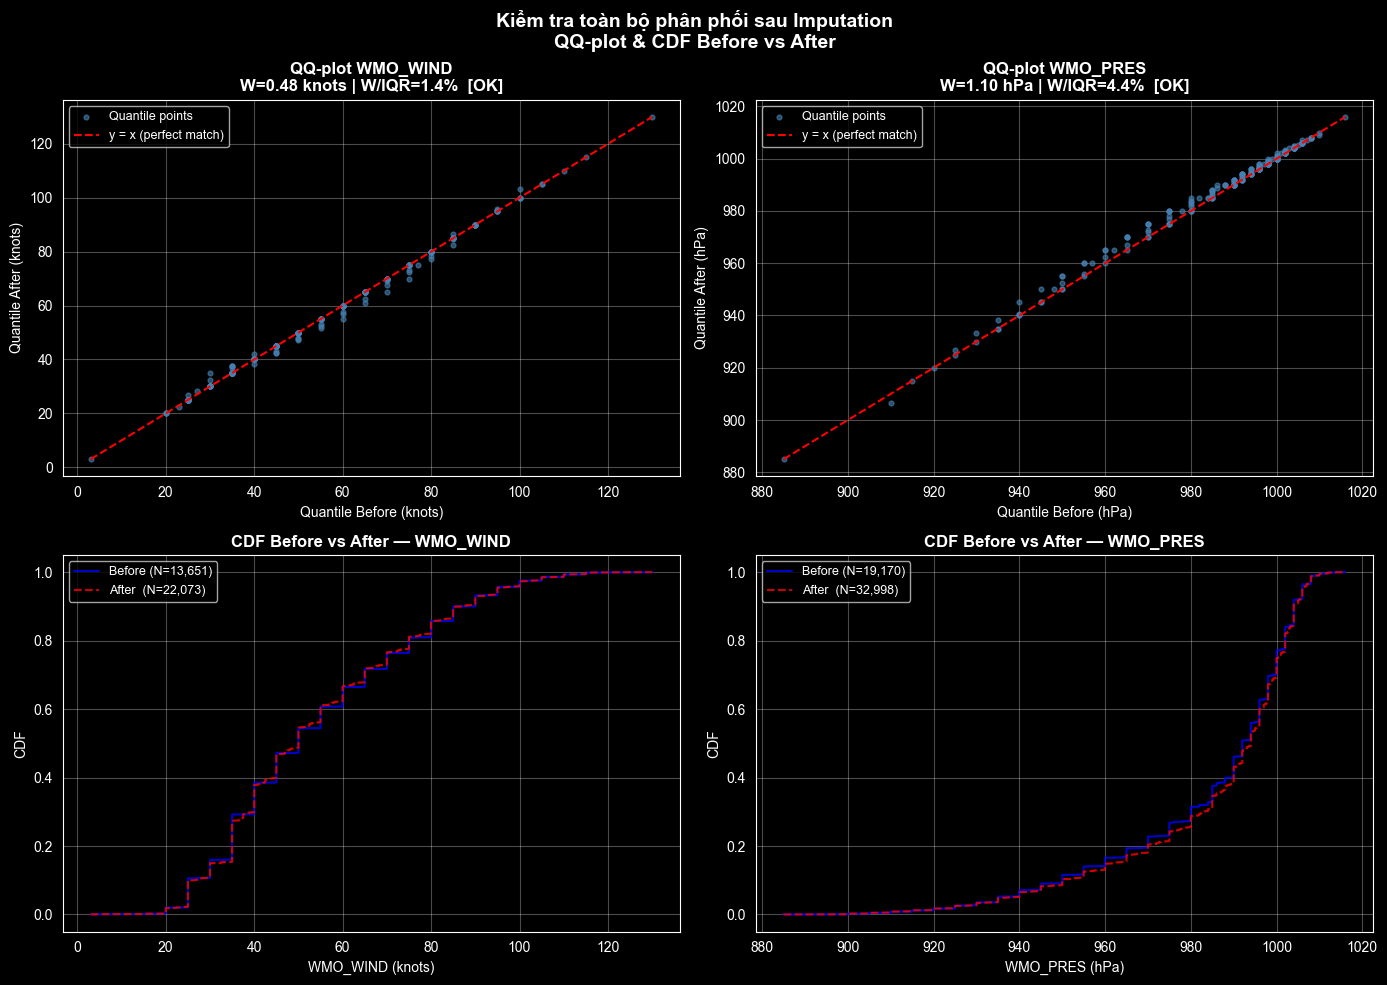

In [16]:
"""
KIỂM TRA BẢO TOÀN PHÂN PHỐI SAU IMPUTATION
Phương pháp: QQ-plot + Wasserstein Distance
- QQ-plot: so sánh quantile của phân phối before vs after.
Nếu các điểm bám sát đường y = x → hai phân phối tương đồng.
- Wasserstein Distance (Earth Mover's Distance):
+ Đo "công" cần thiết để biến phân phối before thành after.
+ Không bị ảnh hưởng bởi sample size lớn (khác KS p-value).
+ Ngưỡng dùng: W / IQR_before < 0.10 (tức < 10% độ trải của phân phối gốc)
→ Ngưỡng tương đối, không phụ thuộc đơn vị đo, có căn cứ thống kê.
→ Nếu Wasserstein chỉ bằng một phần nhỏ IQR thì sự dịch chuyển
+ không đáng kể về mặt thực tế dù N lớn.
"""

from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

cols_numeric = ['WMO_WIND', 'WMO_PRES']
units        = {'WMO_WIND': 'knots', 'WMO_PRES': 'hPa'}
THRESHOLD_RATIO = 0.10   # W/IQR < 10% → bảo toàn tốt

print("BẢO TOÀN PHÂN PHỐI — WASSERSTEIN DISTANCE (chuẩn hóa theo IQR)")
print(f"Ngưỡng: Wasserstein / IQR_before < {THRESHOLD_RATIO:.0%}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Kiểm tra toàn bộ phân phối sau Imputation\n"
             "QQ-plot & CDF Before vs After", fontsize=14, fontweight="bold")

for idx, col in enumerate(cols_numeric):
    before_vals = df_original[col].dropna().values
    after_vals  = df[col].dropna().values

    wd   = wasserstein_distance(before_vals, after_vals)
    iqr  = np.percentile(before_vals, 75) - np.percentile(before_vals, 25)
    ratio = wd / iqr
    unit  = units[col]
    verdict = "Bảo toàn tốt" if ratio < THRESHOLD_RATIO else "Có dịch chuyển nhẹ"

    print(f"\n{col}:")
    print(f"  Wasserstein Distance : {wd:.4f} {unit}")
    print(f"  IQR (before)         : {iqr:.4f} {unit}")
    print(f"  W / IQR              : {ratio:.4f}  ({ratio*100:.1f}% IQR)")
    print(f"  Ngưỡng               : < {THRESHOLD_RATIO:.0%} IQR")
    print(f"  Kết luận             : [{'OK' if ratio < THRESHOLD_RATIO else '!!'}] {verdict}")

    # QQ-plot
    n_quantiles = 200
    quantiles   = np.linspace(0, 100, n_quantiles)
    q_before    = np.percentile(before_vals, quantiles)
    q_after     = np.percentile(after_vals,  quantiles)

    ax = axes[0, idx]
    ax.scatter(q_before, q_after, s=12, alpha=0.6, color="steelblue", label="Quantile points")
    lim_min = min(q_before.min(), q_after.min())
    lim_max = max(q_before.max(), q_after.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color="red", linewidth=1.5, linestyle="--", label="y = x (perfect match)")
    ax.set_xlabel(f"Quantile Before ({unit})", fontsize=10)
    ax.set_ylabel(f"Quantile After ({unit})",  fontsize=10)
    ax.set_title(
        f"QQ-plot {col}\n"
        f"W={wd:.2f} {unit} | W/IQR={ratio*100:.1f}%  [{'OK' if ratio < THRESHOLD_RATIO else '!!'}]",
        fontweight="bold"
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # CDF overlay
    ax2 = axes[1, idx]
    sorted_before = np.sort(before_vals)
    sorted_after  = np.sort(after_vals)
    cdf_before = np.arange(1, len(sorted_before)+1) / len(sorted_before)
    cdf_after  = np.arange(1, len(sorted_after)+1)  / len(sorted_after)
    ax2.plot(sorted_before, cdf_before, color="blue",  linewidth=1.5,
             label=f"Before (N={len(before_vals):,})", alpha=0.8)
    ax2.plot(sorted_after,  cdf_after,  color="red",   linewidth=1.5,
             label=f"After  (N={len(after_vals):,})",  alpha=0.8, linestyle="--")
    ax2.set_xlabel(f"{col} ({unit})", fontsize=10)
    ax2.set_ylabel("CDF", fontsize=10)
    ax2.set_title(f"CDF Before vs After — {col}", fontweight="bold")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Nhận xét:

QQ-plot:

- WMO_WIND: W/IQR=1.4% — các quantile bám sát y=x gần như hoàn toàn, chỉ lệch nhẹ ở vùng cường độ cao (>80 knots) do số điểm extreme ít.
- WMO_PRES: W/IQR=4.4% — bám tốt ở vùng trung tâm, lệch nhẹ ở hai đuôi (áp suất rất thấp <910 hPa và rất cao >1000 hPa) — vùng ít quan sát, không đáng lo.

CDF:

Cả hai biến: đường Before và After gần như chồng khít — phân phối tổng thể được bảo toàn dù số điểm tăng đáng kể (WMO_WIND: 13,651→22,073; WMO_PRES: 19,170→32,998).

Kết luận: Cả QQ-plot lẫn CDF đều xác nhận imputation không làm lệch phân phối — W/IQR dưới ngưỡng 10% ở cả hai biến. Phân phối gốc được bảo toàn tốt.

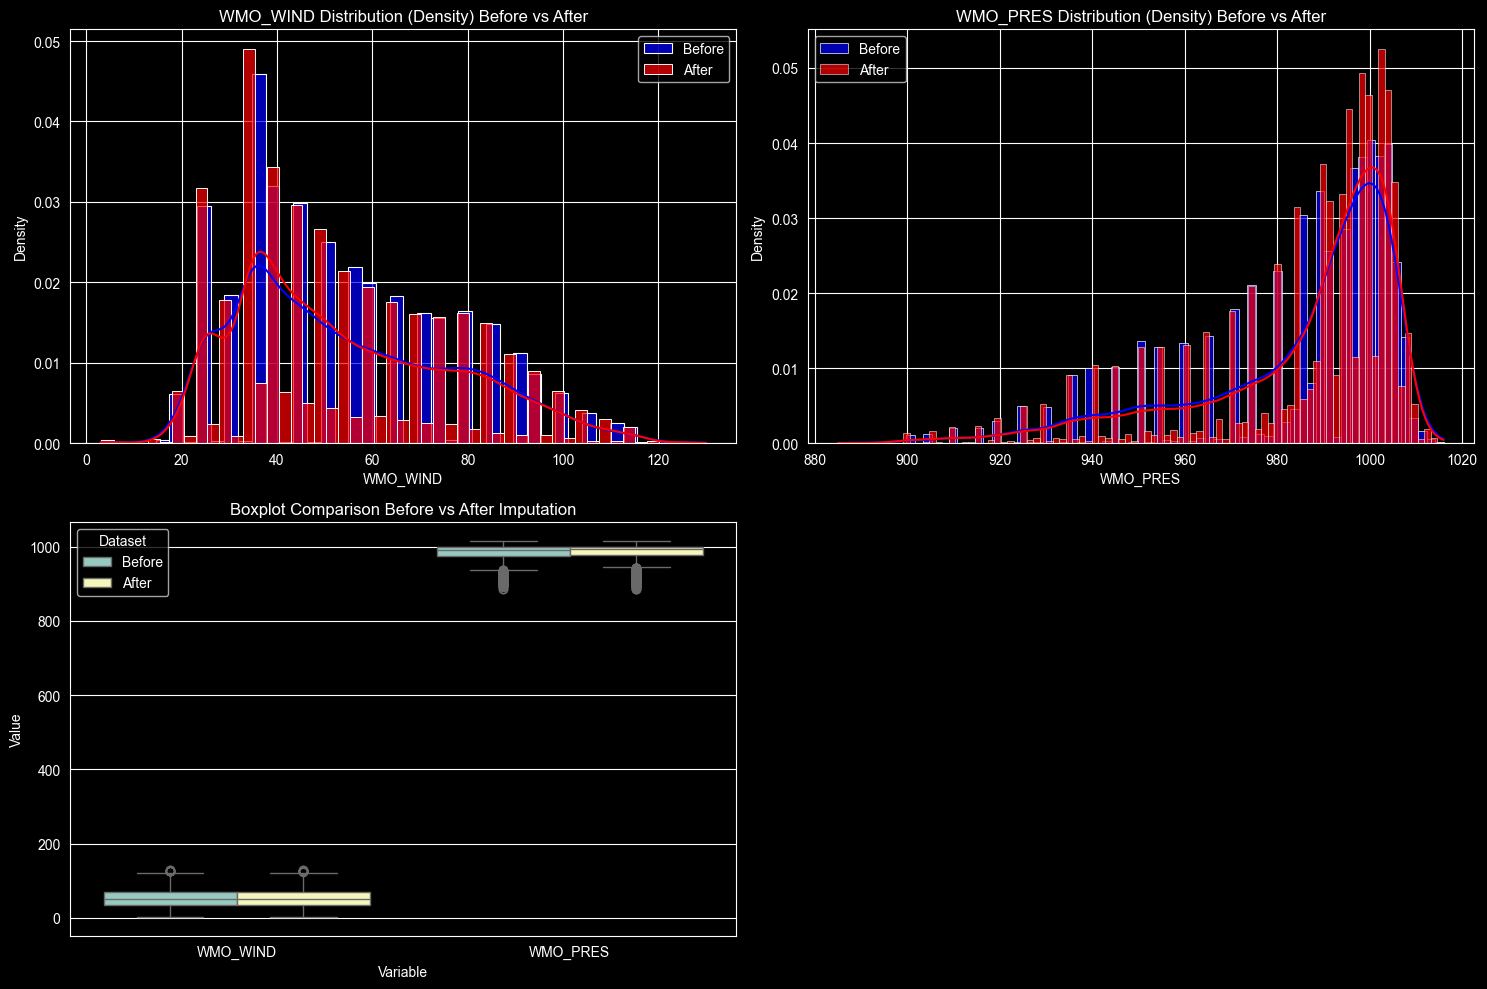

In [17]:
import seaborn as sns

# Tạo figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# HISTOGRAM (dùng density)
# Wind
sns.histplot(df_original['WMO_WIND'], stat='density', kde=True,
             ax=axes[0,0], color='blue', label='Before', alpha=0.7)
sns.histplot(df['WMO_WIND'], stat='density', kde=True,
             ax=axes[0,0], color='red', label='After', alpha=0.7)
axes[0,0].set_title('WMO_WIND Distribution (Density) Before vs After')
axes[0,0].legend()

# Pressure
sns.histplot(df_original['WMO_PRES'], stat='density', kde=True,
             ax=axes[0,1], color='blue', label='Before', alpha=0.7)
sns.histplot(df['WMO_PRES'], stat='density', kde=True,
             ax=axes[0,1], color='red', label='After', alpha=0.7)
axes[0,1].set_title('WMO_PRES Distribution (Density) Before vs After')
axes[0,1].legend()

# BOXPLOT
df_compare = pd.concat([
    df_original[cols_numeric].assign(Dataset='Before'),
    df[cols_numeric].assign(Dataset='After')
])

df_melt = pd.melt(df_compare, id_vars=['Dataset'],
                  var_name='Variable', value_name='Value')

sns.boxplot(data=df_melt, x='Variable', y='Value', hue='Dataset',
            ax=axes[1,0])
axes[1,0].set_title('Boxplot Comparison Before vs After Imputation')

# Ẩn subplot không dùng
axes[1,1].set_visible(False)

plt.tight_layout()
plt.show()

Nhận xét:

WMO_WIND (histogram):

- Sau imputation, mật độ tăng rõ ở vùng 20–35 knots - PCHIP bổ sung nhiều điểm cường độ thấp ở đầu/cuối track (giai đoạn hình thành và tan bão).
- Hình dạng phân phối tổng thể được bảo toàn - đuôi phải (cường độ cao >80 knots) không thay đổi.

WMO_PRES (histogram):

- Mật độ tăng rõ ở vùng 990–1010 hPa, nhất quán với WMO_WIND - cùng bổ sung điểm giai đoạn bão yếu.
- KDE After bám sát KDE Before, chỉ dịch nhẹ về phía áp suất cao hơn.

Boxplot:

- WMO_WIND: median và IQR gần như không đổi, whisker thu hẹp nhẹ - imputation không tạo outlier mới (outlier cũ vẫn giữ nguyên).
- WMO_PRES: tương tự, box dịch nhẹ lên nhưng không đáng kể.

Kết luận: Cả histogram lẫn boxplot đều xác nhận imputation chỉ bổ sung điểm ở vùng cường độ thấp - phù hợp về mặt vật lý, không làm lệch phân phối tổng thể.

In [18]:
print("=== KIỂM TRA BIẾN NATURE SAU IMPUTATION ===\n")

# So sánh trước và sau
print("Phân bố NATURE trước imputation:")
print(df_original['NATURE'].value_counts(dropna=False))

print("\nPhân bố NATURE sau imputation:")
print(df['NATURE'].value_counts())

# Kiểm tra theo BASIN
print("\nTỷ lệ NATURE theo BASIN sau imputation:")
nature_by_basin = pd.crosstab(df['BASIN'], df['NATURE'], normalize='index') * 100
print(nature_by_basin.round(2))

=== KIỂM TRA BIẾN NATURE SAU IMPUTATION ===

Phân bố NATURE trước imputation:
NATURE
Tropical         30918
Mixture           3732
Disturbance       2684
Extratropical     2588
NaN                913
Subtropical         12
Name: count, dtype: int64

Phân bố NATURE sau imputation:
NATURE
Tropical         31831
Mixture           3732
Disturbance       2684
Extratropical     2588
Subtropical         12
Name: count, dtype: int64

Tỷ lệ NATURE theo BASIN sau imputation:
NATURE                 Disturbance  Extratropical  Mixture  Subtropical  \
BASIN                                                                     
Eastern North Pacific        38.93          43.51     1.53         0.00   
North India                   9.13           0.00     2.61         0.00   
South Indian                 13.25           2.41    10.98         0.00   
Western North Pacific         5.89           7.30    10.18         0.03   

NATURE                 Tropical  
BASIN                            
Eastern Nor

Nhận xét:
- Toàn bộ 913 giá trị thiếu của biến NATURE đã được bổ sung thành công (tỷ lệ fill 100%).
- Số lượng mẫu thuộc nhóm Tropical tăng từ 30.918 lên 31.831.
- Phân bố tổng thể của biến NATURE hầu như không thay đổi đáng kể, do phần missing chỉ chiếm tỷ lệ nhỏ (~2.24%).

Đánh giá:

Việc sử dụng mode theo BASIN là hợp lý, giúp bảo toàn đặc trưng khí tượng tự nhiên của từng khu vực (ví dụ: Western North Pacific, North India, South Indian chủ yếu là Tropical; Eastern North Pacific là ngoại lệ với mode là Extratropical - 43.51%). Sau imputation, biến NATURE đã sạch hoàn toàn (không còn missing values).

Kết luận: Phương pháp imputation cho biến NATURE cho kết quả tốt, logic và phù hợp.